<a href="https://colab.research.google.com/github/kannedarihariprasad/-AI-Resume-Screening-System/blob/main/AI_Resume_Screening_System_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
import pandas as pd

data = pd.read_csv("resume_data.xlsx.csv")

In [ ]:
print(data.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [ ]:
data.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
data = pd.read_csv("resume_data.xlsx.csv")

print(data.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [ ]:
print(data.shape)

data.info()

(2484, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
data.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [ ]:
print(data.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [ ]:
data = data[["Resume_str", "Category"]]

In [ ]:
data.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [ ]:
import re

def clean_resume(text):

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"www\S+", " ", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.lower()

In [ ]:
data["Clean_Resume"] = data["Resume_str"].apply(clean_resume)

In [ ]:
data[["Category","Clean_Resume"]].head()

,Category,Clean_Resume
0,HR,hr administrator marketing associate hr admin...
1,HR,hr specialist us hr operations summary versat...
2,HR,hr director summary over years experience in ...
3,HR,hr specialist summary dedicated driven and dy...
4,HR,hr manager skill highlights hr skills hr depa...


In [ ]:
job_description = """
Python Developer

Skills Required:

Python

Machine Learning

Pandas

NumPy

Scikit-learn

Data Analysis

SQL

Deep Learning

TensorFlow

Keras
"""

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")

In [ ]:
resume_vectors = tfidf.fit_transform(data["Clean_Resume"])

job_vector = tfidf.transform([job_description])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(job_vector, resume_vectors)

In [ ]:
data["Match_Percentage"] = similarity[0] * 100

In [ ]:
ranking = data.sort_values(
    by="Match_Percentage",
    ascending=False
)

In [ ]:
ranking[["Category","Match_Percentage"]].head(10)

,Category,Match_Percentage
926,AGRICULTURE,25.809496
1339,AUTOMOBILE,19.186797
1762,ENGINEERING,14.663347
2153,BANKING,12.868999
1218,CONSULTANT,12.427490
929,AGRICULTURE,11.686615
1303,DIGITAL-MEDIA,10.429419
2291,ARTS,10.328148
1756,ENGINEERING,10.292686
1348,AUTOMOBILE,9.964714


In [ ]:
ranking[["Category","Match_Percentage"]].head(20)

,Category,Match_Percentage
926,AGRICULTURE,25.809496
1339,AUTOMOBILE,19.186797
1762,ENGINEERING,14.663347
2153,BANKING,12.868999
1218,CONSULTANT,12.427490
929,AGRICULTURE,11.686615
1303,DIGITAL-MEDIA,10.429419
2291,ARTS,10.328148
1756,ENGINEERING,10.292686
1348,AUTOMOBILE,9.964714


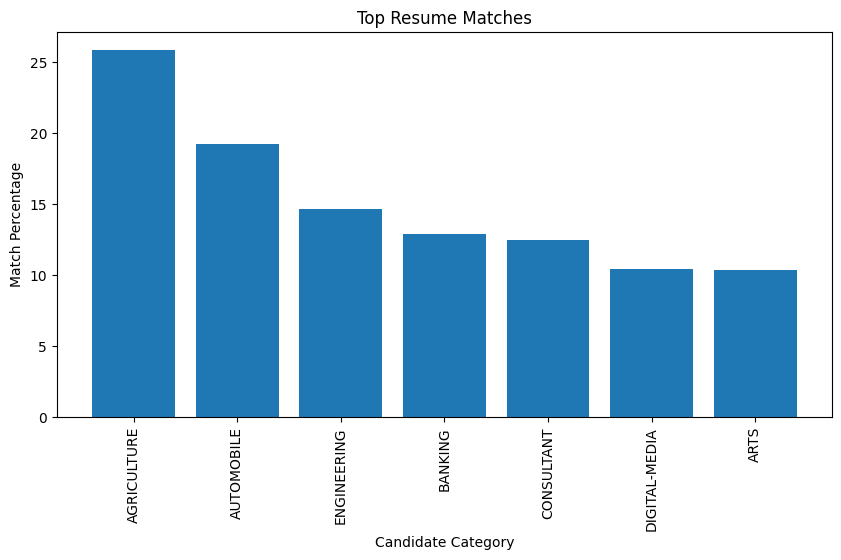

In [ ]:
top10 = ranking.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["Category"], top10["Match_Percentage"])

plt.xticks(rotation=90)

plt.title("Top Resume Matches")

plt.xlabel("Candidate Category")

plt.ylabel("Match Percentage")

plt.show()

In [ ]:
best = ranking.iloc[0]

print("Best Candidate Category :", best["Category"])

print("Matching Percentage :", round(best["Match_Percentage"],2),"%")

Best Candidate Category : AGRICULTURE
Matching Percentage : 25.81 %


In [ ]:
ranking.to_csv("Resume_Ranking.csv", index=False)